In [2]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantity import * 
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector, Statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize(linewidth=2)
fig_dir, data_dir = './figs', './data'

In [53]:
n = 8 # 10
t = 10  
r = 100 # 100

dt = t/r
# H_model = 'MFI'
# hx, hy, Jx = 1, 0.9, 0.8
Jx, hx, hy = 1, 0.8, 0.9
print(f't={t}, r={r}, dt={dt}')

# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
ob_op = z1
obs = ob_op.to_matrix()
complete_fnorm = 2**(-n/2)*np.linalg.norm(obs, ord='fro')

t=10, r=100, dt=0.1


In [54]:
## QMFI
qmfi = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
qmfi_xx_even = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[::2]], num_qubits=n).simplify()
qmfi_xx_odd = SparsePauliOp.from_sparse_list([*qmfi.xx_tuples[1::2]], num_qubits=n).simplify()
qmfi_x_terms = SparsePauliOp.from_sparse_list([*qmfi.x_tuples], num_qubits=n).simplify()
qmfi_y_terms = qmfi.y_terms
qmfi_H_list = [qmfi_x_terms, qmfi_y_terms, qmfi_xx_even, qmfi_xx_odd] 
qmfi_H_ordered = sum(qmfi_H_list)
qmfi_U_dt_ideal = expH(sum(qmfi_H_ordered), dt, use_jax=False)
qmfi_U_dt_appro = pf(qmfi_H_ordered, dt, 1, 1)

qmfi_ideal_ops = [matrix_power(qmfi_U_dt_ideal, i) for i in range(r+1)]
qmfi_trott_ops = [matrix_power(qmfi_U_dt_appro, i) for i in range(r+1)]

print('evoluate states...')
qmfi_ideal_states = [qmfi_ideal_ops[i]@init_state for i in range(r+1)]
qmfi_trott_states = [qmfi_trott_ops[i]@init_state for i in range(r+1)]
print('evoluate obs...')
qmfi_trott_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_trott_ops]
qmfi_ideal_obs = [op.conjugate().transpose() @ obs @ op for op in qmfi_ideal_ops]
print('evoluate expvals...')
qmfi_ideal_expvals = [expect_value(obs, qmfi_ideal_states[i]) for i in range(r+1)]
qmfi_trott_expvals = [expect_value(obs, qmfi_trott_states[i]) for i in range(r+1)]

qmfi_ops = dt*sum(qmfi_H_list)
# print('ops:', ops)
# print('obs:', obs)

evoluate states...
evoluate obs...
evoluate expvals...


In [55]:
exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

w_thres = 5
qmfi_sim = LowWeightPauliPropagation.from_pauli_list(ob_op, qmfi_ops, threshold=w_thres, nprocs=4)
qmfi_res = qmfi_sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
qmfi_res = np.array(qmfi_res)
qmfi_norm_weight_steps = [weight_2norm_distr(ob, n) for ob in qmfi_sim.evo_obs]

sub_dim = 3
qmfi_entangle_entropy3 = [entangle_entropy(state, sub_dim) for state in qmfi_trott_states]
qmfi_magic = [operator_magic(obs) for obs in qmfi_sim.evo_obs]

100%|██████████| 100/100 [00:04<00:00, 20.79it/s]


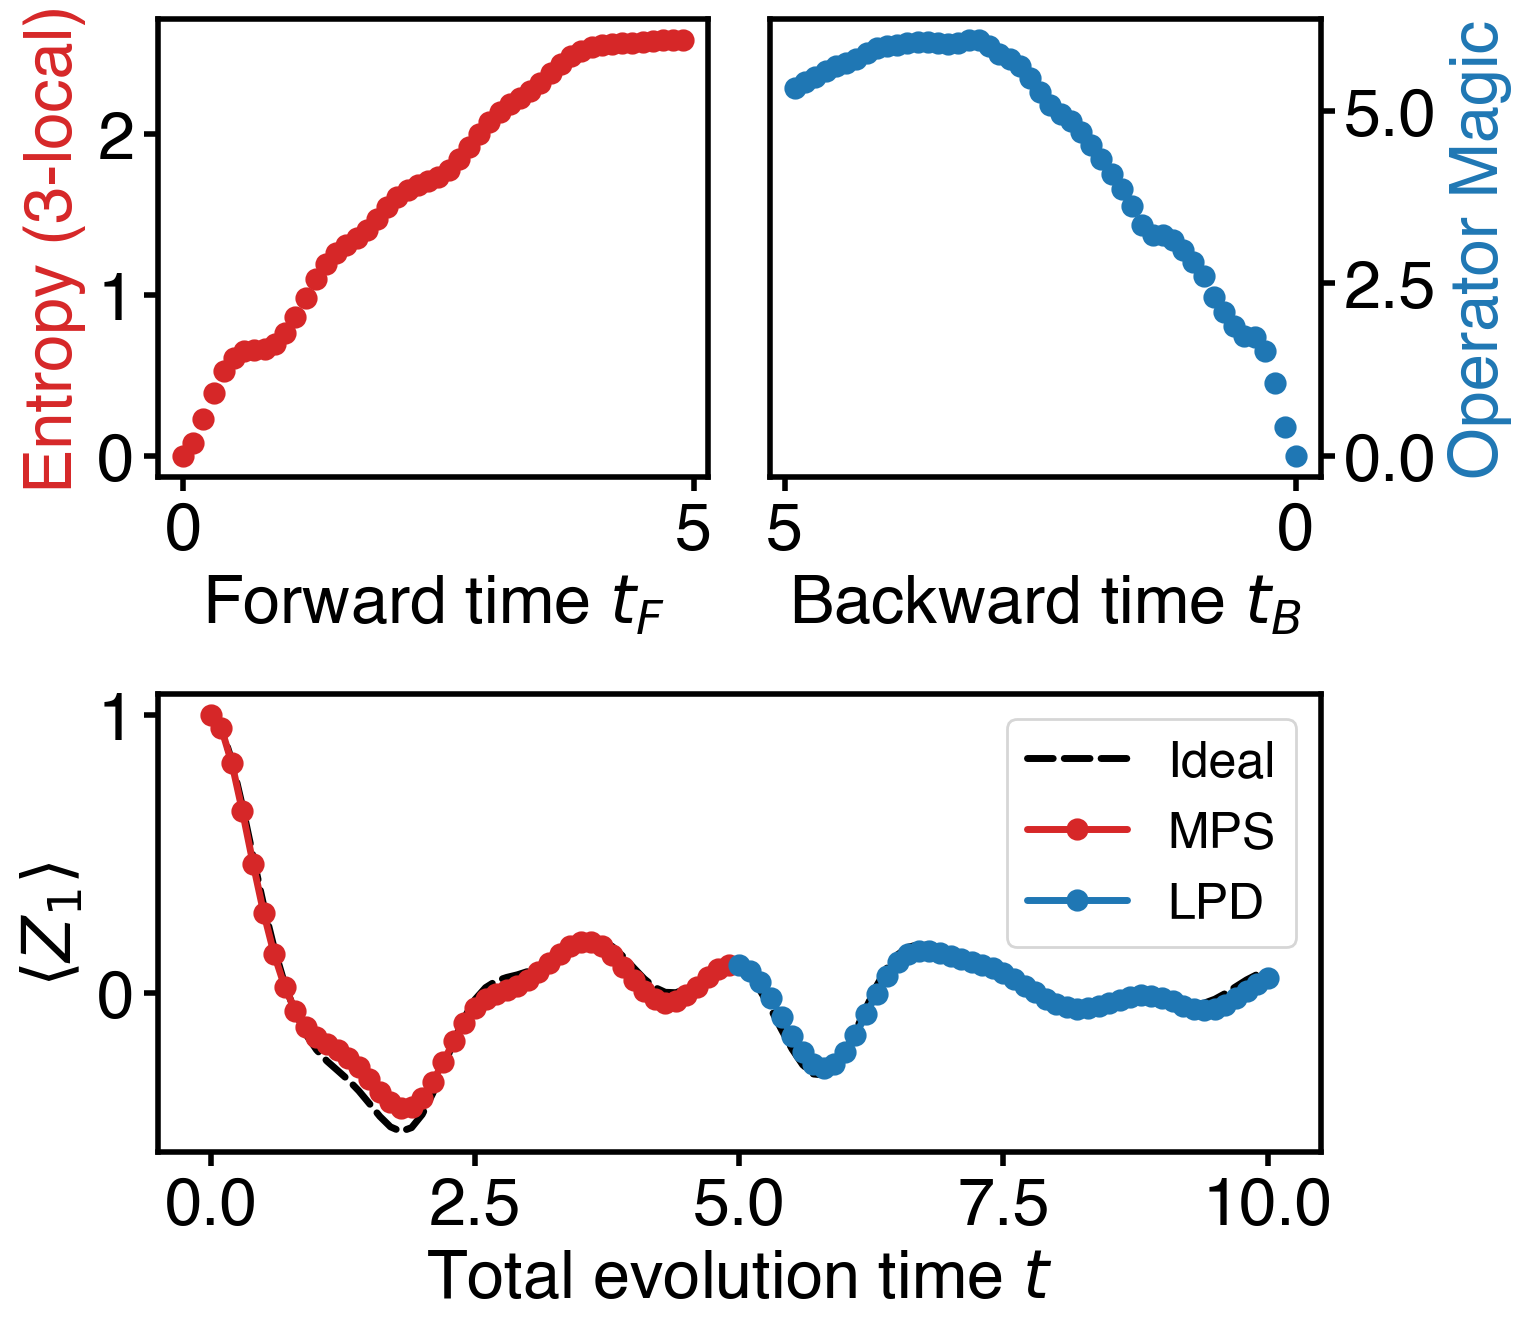

In [60]:
t_list = [i*dt for i in range(r+1)]
r2 = r//2

fig = plt.figure(figsize=(8, 7))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
# Create the wide rectangular plot in the second row (spanning both columns)
ax3 = plt.subplot(2, 1, 2)

ax1.plot(t_list[:r2], qmfi_entangle_entropy3[:r2], '.', label='MFI', c='tab:red')
ax1.set_ylabel(f'Entropy ({sub_dim}-local)', c='tab:red')
ax1.set_xlabel(rf'Forward time $t_F$')
ax2.plot(t_list[:r2], qmfi_magic[:r2], '.', label='MFI', c='tab:blue')
ax2.invert_xaxis()
ax2.set_ylabel('Operator Magic', c='tab:blue')
ax2.set_xlabel(rf'Backward time $t_B$')
ax2.yaxis.set_label_position("right")  # Move y-axis label to the right
ax2.yaxis.tick_right()

ax3.plot(t_list, qmfi_ideal_expvals, '--', label='Ideal', c='k')
ax3.plot(t_list[:r2], qmfi_trott_expvals[:r2], '.-', label='MPS', c='tab:red')
ax3.plot(t_list[r2:], qmfi_trott_expvals[r2:], '.-', label='LPD', c='tab:blue')
ax3.set_ylabel(rf'$\langle Z_1 \rangle$')
ax3.set_xlabel(rf'Total evolution time $t$')
ax3.legend()

# for ax, label in zip([ax1, ax2, ax3], ['a', 'b', 'c']): 
#     ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/hybrid_n={n}_t={t}_r={r}.pdf', bbox_inches='tight')